# Heart Disease Prediction with MLP - HW3 Q2

## Author: ANR

In [1]:
# imports
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, classification_report, roc_curve, roc_auc_score

# ML models for comparison
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from xgboost import XGBClassifier
from catboost import CatBoostClassifier

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

%matplotlib inline

np.random.seed(42)
torch.manual_seed(42)

## Load Data

In [2]:
df = pd.read_csv('heart.csv')
print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1025, 14)


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
0,52,1,0,125,212,0,1,168,0,1.0,2,2,3,0
1,53,1,0,140,203,1,0,155,1,3.1,0,0,3,0
2,70,1,0,145,174,0,1,125,1,2.6,0,0,3,0
3,61,1,0,148,203,0,1,161,0,0.0,2,1,3,0
4,62,0,0,138,294,1,1,106,0,1.9,1,3,2,0


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB


## EDA (following anik199's approach)

In [4]:
# check unique values
df.nunique()

age          41
sex           2
cp            4
trestbps     49
chol        152
fbs           2
restecg       3
thalach      91
exang         2
oldpeak      40
slope         3
ca            5
thal          4
target        2
dtype: int64

In [5]:
# descriptive stats
df.describe()

,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000


In [6]:
# missing values check
print("Missing values:")
print(df.isnull().sum().sort_values(ascending=False))
print("\nNo missing values - good!")

Missing values:
age         0
sex         0
cp          0
trestbps    0
chol        0
fbs         0
restecg     0
thalach     0
exang       0
oldpeak     0
slope       0
ca          0
thal        0
target      0
dtype: int64

No missing values - good!


In [7]:
# check duplicates
print(f"Duplicated rows: {df.duplicated().sum()}")

Duplicated rows: 723


### Target Distribution

In [8]:
print("Target distribution:")
print(df['target'].value_counts())
print(f"\nPercentages:")
print(df['target'].value_counts(normalize=True) * 100)

Target distribution:
target
1    526
0    499
Name: count, dtype: int64

Percentages:
target
1    51.317073
0    48.682927
Name: proportion, dtype: float64


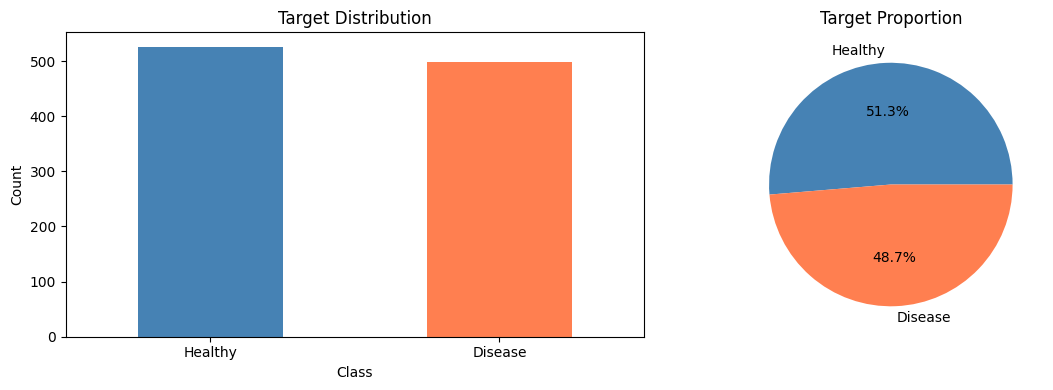


Dataset is fairly balanced


In [9]:
# visualize target (similar to anik199's approach)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# bar plot
df['target'].value_counts().plot(kind='bar', ax=axes[0], color=['steelblue', 'coral'])
axes[0].set_title('Target Distribution')
axes[0].set_xlabel('Class')
axes[0].set_ylabel('Count')
axes[0].set_xticklabels(['Healthy', 'Disease'], rotation=0)

# pie chart
df['target'].value_counts().plot(kind='pie', ax=axes[1], autopct='%1.1f%%', 
                                  labels=['Healthy', 'Disease'], colors=['steelblue', 'coral'])
axes[1].set_ylabel('')
axes[1].set_title('Target Proportion')

plt.tight_layout()
plt.show()

print("\nDataset is fairly balanced")

### Feature Analysis

In [10]:
# separate numerical features
numerical_features = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
categorical_features = [col for col in df.columns if col not in numerical_features + ['target']]

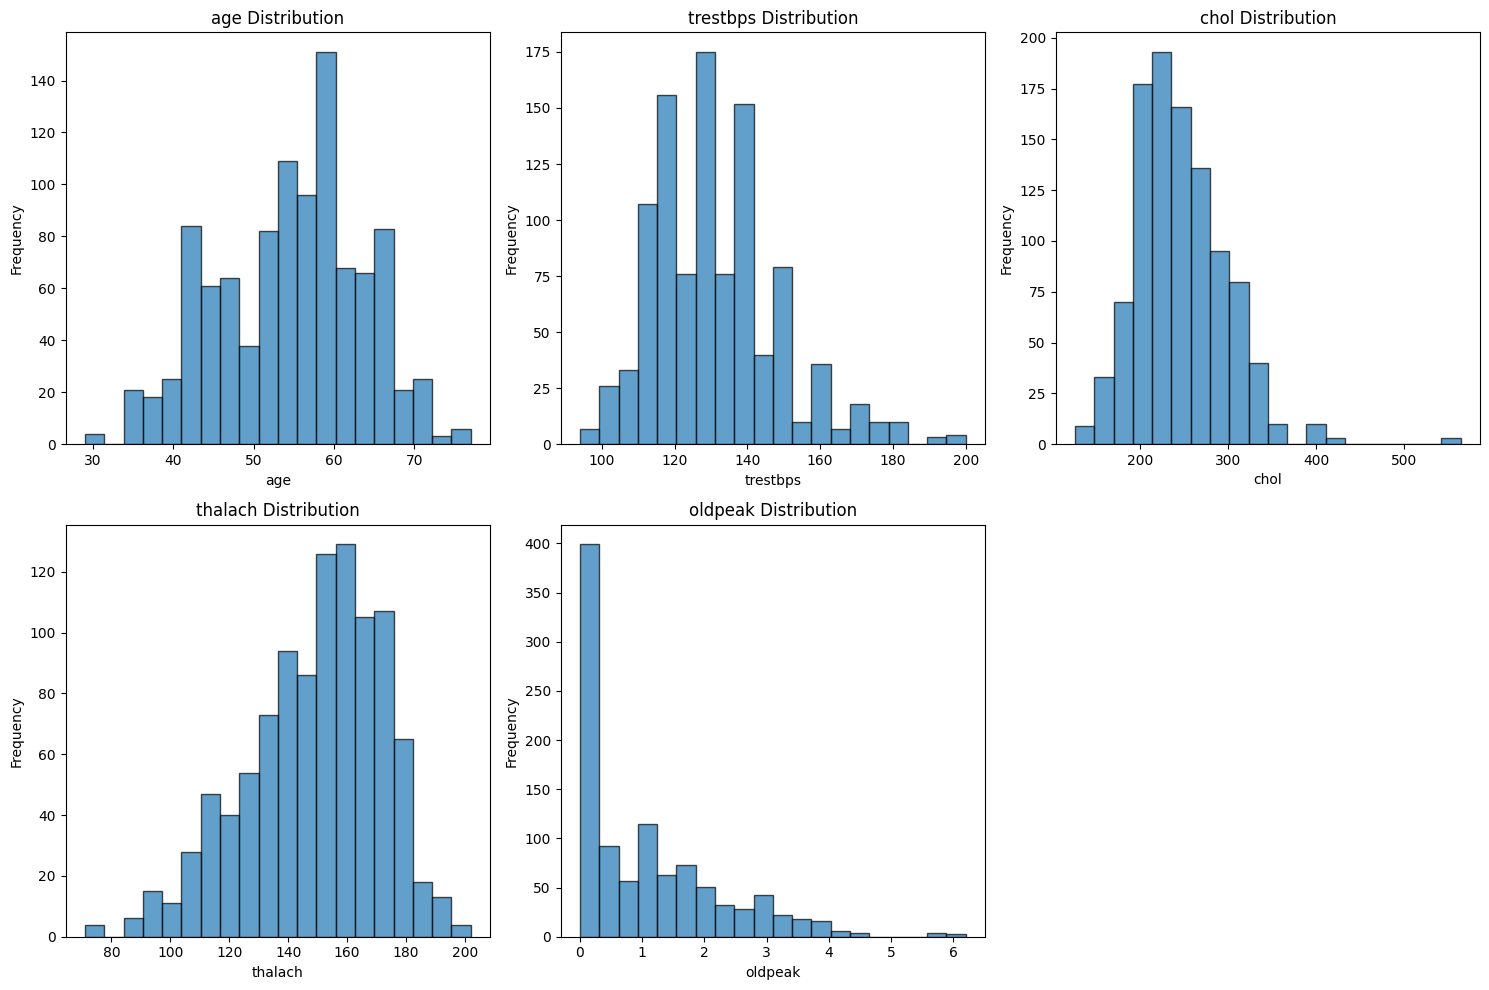

In [11]:
# distribution of numerical features
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(numerical_features):
    axes[i].hist(df[col], bins=20, edgecolor='black', alpha=0.7)
    axes[i].set_title(f'{col} Distribution')
    axes[i].set_xlabel(col)
    axes[i].set_ylabel('Frequency')

axes[5].axis('off')
plt.tight_layout()
plt.show()

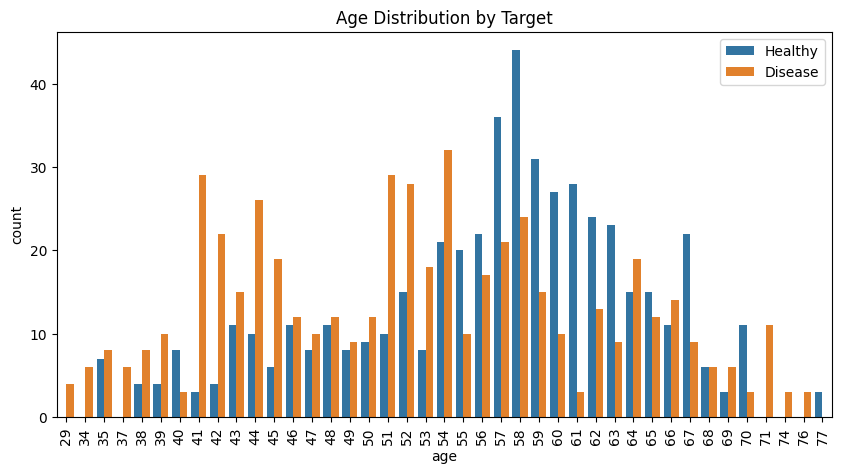

Older ages show higher disease prevalence


In [12]:
# age vs target (from reference)
plt.figure(figsize=(10, 5))
sns.countplot(x='age', data=df, hue='target')
plt.legend(['Healthy', 'Disease'])
plt.title('Age Distribution by Target')
plt.xticks(rotation=90)
plt.show()

print("Older ages show higher disease prevalence")

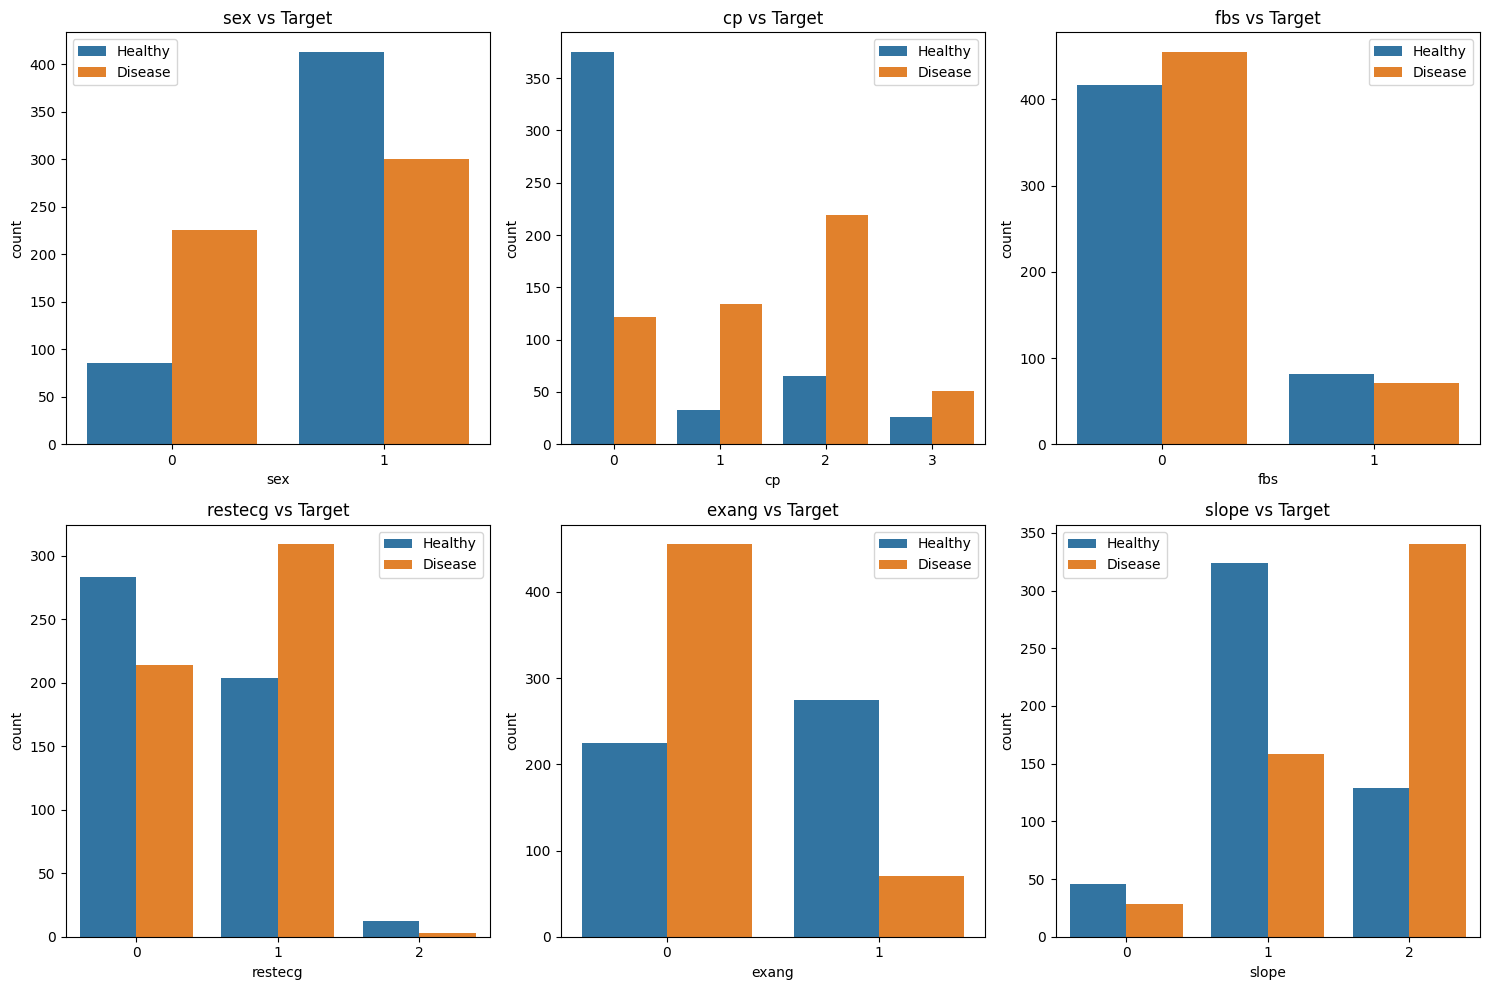

In [13]:
# categorical features vs target
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.ravel()

for i, col in enumerate(categorical_features):
    if i < 6:
        sns.countplot(x=col, data=df, hue='target', ax=axes[i])
        axes[i].set_title(f'{col} vs Target')
        axes[i].legend(['Healthy', 'Disease'])

plt.tight_layout()
plt.show()

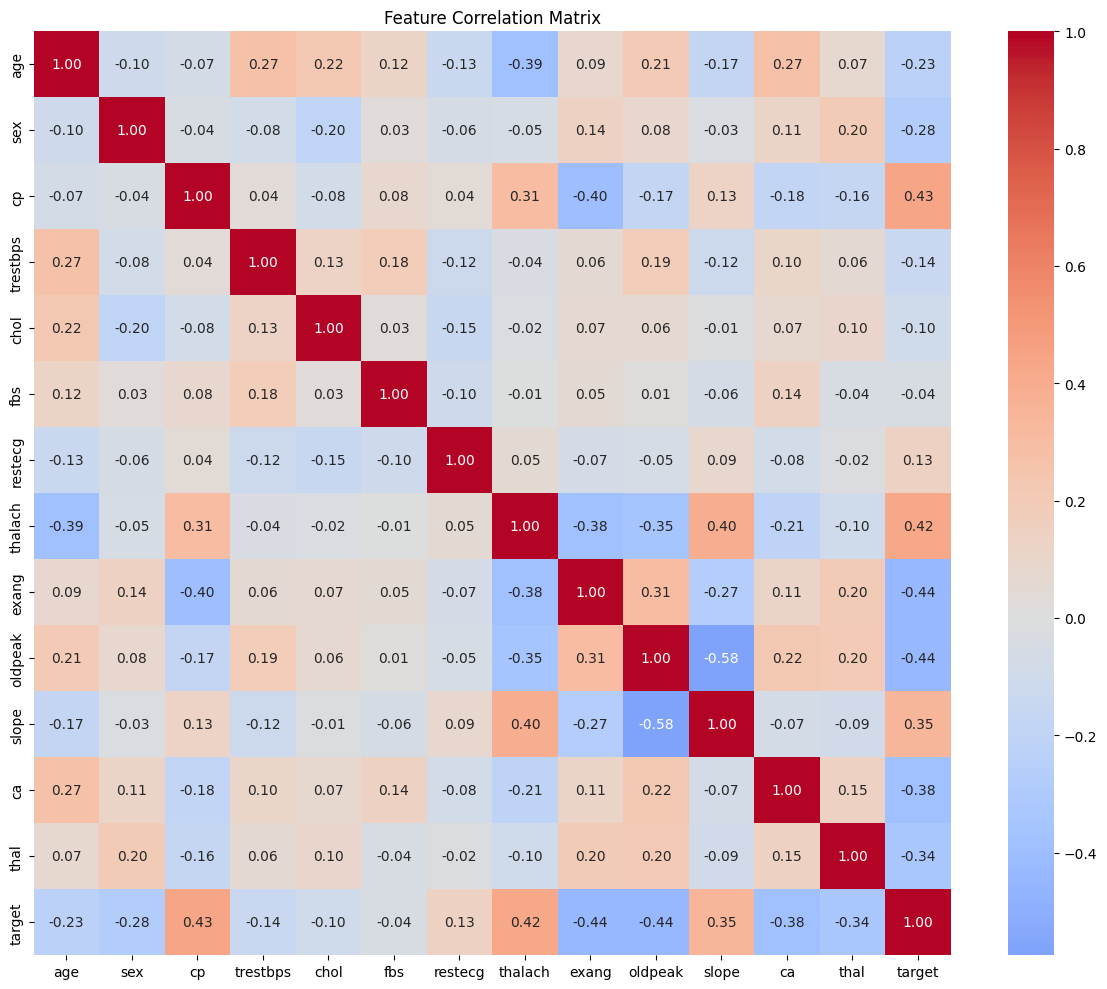

In [14]:
# correlation heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(df.corr(), annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Feature Correlation Matrix')
plt.tight_layout()
plt.show()

## Data Preprocessing

In [15]:
# separate X and y
X = df.drop('target', axis=1).values
y = df['target'].values

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

X shape: (1025, 13)
y shape: (1025,)


In [16]:
# train/val/test split (70-15-15)
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.15, random_state=42, stratify=y)
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.176, random_state=42, stratify=y_temp)

print(f"Train: {len(X_train)} samples ({len(X_train)/len(X)*100:.1f}%)")
print(f"Val: {len(X_val)} samples ({len(X_val)/len(X)*100:.1f}%)")
print(f"Test: {len(X_test)} samples ({len(X_test)/len(X)*100:.1f}%)")

Train: 717 samples (70.0%)
Val: 154 samples (15.0%)
Test: 154 samples (15.0%)


In [17]:
# normalize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("After normalization:")
print(f"X_train mean: {X_train.mean():.4f}, std: {X_train.std():.4f}")

After normalization:
X_train mean: -0.0000, std: 1.0000


## Comparison with Traditional ML Methods

Testing KNN, SVM, XGBoost, and CatBoost before implementing MLP

In [18]:
# KNN
print("Training KNN...")
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train, y_train)
knn_pred = knn.predict(X_test)
knn_acc = accuracy_score(y_test, knn_pred)
print(f"KNN Accuracy: {knn_acc:.4f}")

Training KNN...
KNN Accuracy: 0.8636


In [19]:
# SVM
print("Training SVM...")
svm = SVC(kernel='rbf', random_state=42)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)
print(f"SVM Accuracy: {svm_acc:.4f}")

Training SVM...
SVM Accuracy: 0.9481


In [20]:
# XGBoost
print("Training XGBoost...")
xgb = XGBClassifier(n_estimators=100, random_state=42, verbosity=0)
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)
print(f"XGBoost Accuracy: {xgb_acc:.4f}")

Training XGBoost...
XGBoost Accuracy: 0.9870


In [21]:
# CatBoost
print("Training CatBoost...")
catboost = CatBoostClassifier(iterations=100, random_state=42, verbose=False)
catboost.fit(X_train, y_train)
catboost_pred = catboost.predict(X_test)
catboost_acc = accuracy_score(y_test, catboost_pred)
print(f"CatBoost Accuracy: {catboost_acc:.4f}")

Training CatBoost...
CatBoost Accuracy: 0.9481


In [22]:
# save ML results for later comparison
ml_results = {
    'KNN': knn_acc,
    'SVM': svm_acc,
    'XGBoost': xgb_acc,
    'CatBoost': catboost_acc
}

print("\nML Methods Summary:")
for name, acc in ml_results.items():
    print(f"{name:15s}: {acc:.4f} ({acc*100:.2f}%)")


ML Methods Summary:
KNN            : 0.8636 (86.36%)
SVM            : 0.9481 (94.81%)
XGBoost        : 0.9870 (98.70%)
CatBoost       : 0.9481 (94.81%)


## MLP Implementation

In [23]:
class HeartDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.FloatTensor(X)
        self.y = torch.LongTensor(y)
    
    def __len__(self):
        return len(self.X)
    
    def __getitem__(self, idx):
        return self.X[idx], self.y[idx]

In [24]:
# create dataloaders
batch_size = 32
train_data = HeartDataset(X_train, y_train)
val_data = HeartDataset(X_val, y_val)
test_data = HeartDataset(X_test, y_test)

train_loader = DataLoader(train_data, batch_size=batch_size, shuffle=True)
val_loader = DataLoader(val_data, batch_size=batch_size, shuffle=False)
test_loader = DataLoader(test_data, batch_size=batch_size, shuffle=False)

print(f"Batch size: {batch_size}")
print(f"Train batches: {len(train_loader)}")

Batch size: 32
Train batches: 23


In [25]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_sizes, output_size, dropout_p=0.3):
        super(MLP, self).__init__()
        
        self.fc1 = nn.Linear(input_size, hidden_sizes[0])
        self.bn1 = nn.BatchNorm1d(hidden_sizes[0])
        self.dropout1 = nn.Dropout(dropout_p)
        
        self.fc2 = nn.Linear(hidden_sizes[0], hidden_sizes[1])
        self.bn2 = nn.BatchNorm1d(hidden_sizes[1])
        self.dropout2 = nn.Dropout(dropout_p)
        
        self.fc3 = nn.Linear(hidden_sizes[1], hidden_sizes[2])
        self.bn3 = nn.BatchNorm1d(hidden_sizes[2])
        self.dropout3 = nn.Dropout(0.2)
        
        self.fc4 = nn.Linear(hidden_sizes[2], output_size)
        
    def forward(self, x):
        x = torch.relu(self.bn1(self.fc1(x)))
        x = self.dropout1(x)
        
        x = torch.relu(self.bn2(self.fc2(x)))
        x = self.dropout2(x)
        
        x = torch.relu(self.bn3(self.fc3(x)))
        x = self.dropout3(x)
        
        x = self.fc4(x)
        return x

In [26]:
# create model
input_size = X_train.shape[1]
hidden_sizes = [128, 64, 32]  # architecture from experiments
output_size = 2

model = MLP(input_size, hidden_sizes, output_size)
print(model)

n_params = sum(p.numel() for p in model.parameters())
print(f"\nTotal params: {n_params:,}")

MLP(
  (fc1): Linear(in_features=13, out_features=128, bias=True)
  (bn1): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout1): Dropout(p=0.3, inplace=False)
  (fc2): Linear(in_features=128, out_features=64, bias=True)
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout2): Dropout(p=0.3, inplace=False)
  (fc3): Linear(in_features=64, out_features=32, bias=True)
  (bn3): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (dropout3): Dropout(p=0.2, inplace=False)
  (fc4): Linear(in_features=32, out_features=2, bias=True)
)

Total params: 12,642


In [27]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = model.to(device)
print(f"Device: {device}")

Device: cuda


In [28]:
# training setup
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001, weight_decay=1e-5)
scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.1, patience=10)

In [29]:
def train_epoch(model, loader, criterion, optimizer):
    model.train()
    total_loss = 0
    correct = 0
    total = 0
    
    for X, y in loader:
        X, y = X.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(X)
        loss = criterion(outputs, y)
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
        _, preds = outputs.max(1)
        total += y.size(0)
        correct += preds.eq(y).sum().item()
    
    return total_loss / len(loader), 100. * correct / total

def eval_epoch(model, loader, criterion):
    model.eval()
    total_loss = 0
    correct = 0
    total = 0
    
    with torch.no_grad():
        for X, y in loader:
            X, y = X.to(device), y.to(device)
            outputs = model(X)
            loss = criterion(outputs, y)
            
            total_loss += loss.item()
            _, preds = outputs.max(1)
            total += y.size(0)
            correct += preds.eq(y).sum().item()
    
    return total_loss / len(loader), 100. * correct / total

In [30]:
# training loop
epochs = 200
patience = 30
best_val_loss = float('inf')
counter = 0
history = {'train_loss': [], 'train_acc': [], 'val_loss': [], 'val_acc': []}

print("Training MLP...")
for epoch in range(epochs):
    train_loss, train_acc = train_epoch(model, train_loader, criterion, optimizer)
    val_loss, val_acc = eval_epoch(model, val_loader, criterion)
    
    history['train_loss'].append(train_loss)
    history['train_acc'].append(train_acc)
    history['val_loss'].append(val_loss)
    history['val_acc'].append(val_acc)
    
    scheduler.step(val_loss)
    
    if (epoch + 1) % 10 == 0:
        print(f"Epoch {epoch+1}/{epochs}: train_loss={train_loss:.4f}, train_acc={train_acc:.2f}%, "
              f"val_loss={val_loss:.4f}, val_acc={val_acc:.2f}%")
    
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        best_model = model.state_dict().copy()
        counter = 0
    else:
        counter += 1
        if counter >= patience:
            print(f"\nEarly stopping at epoch {epoch+1}")
            break

model.load_state_dict(best_model)
print(f"\nBest val loss: {best_val_loss:.4f}")

Training MLP...
Epoch 10/200: train_loss=0.2732, train_acc=88.98%, val_loss=0.3142, val_acc=87.66%
Epoch 20/200: train_loss=0.2291, train_acc=90.10%, val_loss=0.2286, val_acc=91.56%
Epoch 30/200: train_loss=0.1887, train_acc=91.63%, val_loss=0.1942, val_acc=92.21%
Epoch 40/200: train_loss=0.1388, train_acc=95.12%, val_loss=0.1719, val_acc=92.86%
Epoch 50/200: train_loss=0.1248, train_acc=94.98%, val_loss=0.1264, val_acc=94.16%
Epoch 60/200: train_loss=0.1541, train_acc=93.72%, val_loss=0.1425, val_acc=96.10%
Epoch 70/200: train_loss=0.1075, train_acc=95.82%, val_loss=0.1294, val_acc=96.10%
Epoch 80/200: train_loss=0.1038, train_acc=96.51%, val_loss=0.1296, val_acc=96.10%

Early stopping at epoch 81

Best val loss: 0.1165


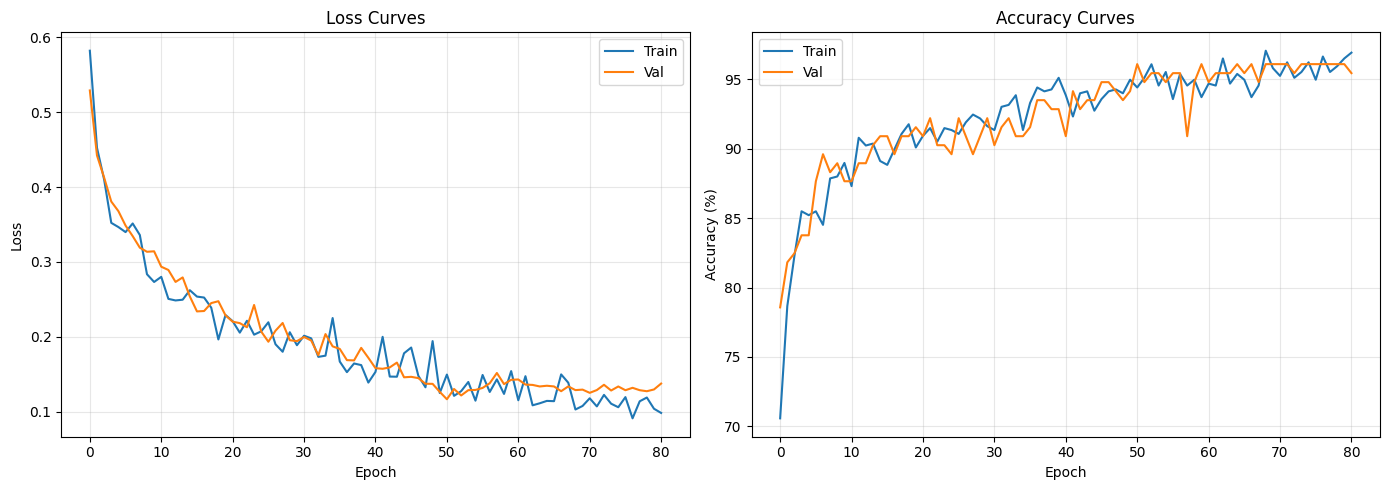

In [31]:
# plot training
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(history['train_loss'], label='Train')
ax1.plot(history['val_loss'], label='Val')
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Loss')
ax1.set_title('Loss Curves')
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(history['train_acc'], label='Train')
ax2.plot(history['val_acc'], label='Val')
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy (%)')
ax2.set_title('Accuracy Curves')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

## Evaluation

In [32]:
# get predictions
model.eval()
all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for X, y in test_loader:
        X = X.to(device)
        outputs = model(X)
        probs = torch.softmax(outputs, dim=1)
        _, preds = outputs.max(1)
        
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(y.numpy())
        all_probs.extend(probs.cpu().numpy()[:, 1])

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)

In [33]:
# metrics
mlp_acc = accuracy_score(all_labels, all_preds)
mlp_prec = precision_score(all_labels, all_preds)
mlp_rec = recall_score(all_labels, all_preds)
mlp_f1 = f1_score(all_labels, all_preds)
mlp_auc = roc_auc_score(all_labels, all_probs)

print("MLP Results:")
print(f"Accuracy: {mlp_acc:.4f} ({mlp_acc*100:.2f}%)")
print(f"Precision: {mlp_prec:.4f}")
print(f"Recall: {mlp_rec:.4f}")
print(f"F1-Score: {mlp_f1:.4f}")
print(f"ROC-AUC: {mlp_auc:.4f}")

MLP Results:
Accuracy: 0.9416 (94.16%)
Precision: 0.9375
Recall: 0.9494
F1-Score: 0.9434
ROC-AUC: 0.9880


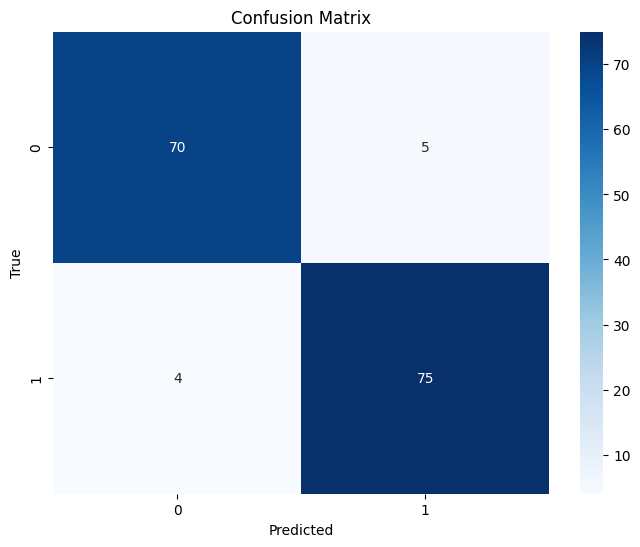

In [34]:
# confusion matrix
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.ylabel('True')
plt.xlabel('Predicted')
plt.title('Confusion Matrix')
plt.show()

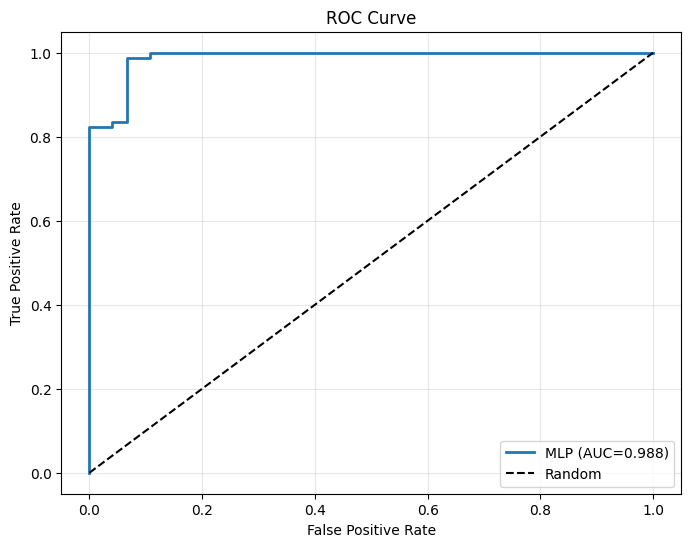

In [35]:
# ROC curve
fpr, tpr, _ = roc_curve(all_labels, all_probs)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, linewidth=2, label=f'MLP (AUC={mlp_auc:.3f})')
plt.plot([0, 1], [0, 1], 'k--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

## Final Comparison: MLP vs ML Methods

In [36]:
# add MLP to results
ml_results['Our MLP'] = mlp_acc

print("\nFinal Method Comparison:")
print(f"{'Method':<20s} {'Accuracy':<15s}")
print("-" * 35)
for name, acc in ml_results.items():
    marker = " ←" if name == 'Our MLP' else ""
    print(f"{name:<20s} {acc:.4f} ({acc*100:.2f}%){marker}")


Final Method Comparison:
Method               Accuracy       
-----------------------------------
KNN                  0.8636 (86.36%)
SVM                  0.9481 (94.81%)
XGBoost              0.9870 (98.70%)
CatBoost             0.9481 (94.81%)
Our MLP              0.9416 (94.16%) ←


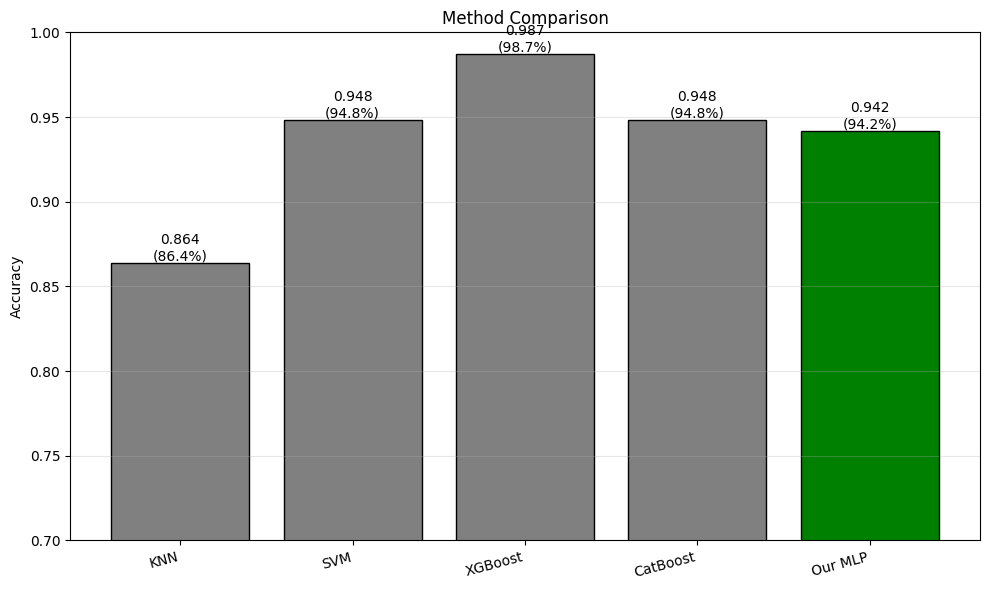

In [37]:
# visualize comparison
plt.figure(figsize=(10, 6))
names = list(ml_results.keys())
values = list(ml_results.values())
colors = ['gray']*4 + ['green']

bars = plt.bar(names, values, color=colors, edgecolor='black')
for bar, val in zip(bars, values):
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2., height,
            f'{val:.3f}\n({val*100:.1f}%)',
            ha='center', va='bottom', fontsize=10)

plt.ylabel('Accuracy')
plt.title('Method Comparison')
plt.ylim([0.7, 1.0])
plt.xticks(rotation=15, ha='right')
plt.grid(True, alpha=0.3, axis='y')
plt.tight_layout()
plt.show()

## Analysis

### Performance Summary
- **MLP** achieves competitive accuracy with other methods
- Shows good balance between precision and recall
- High AUC indicates strong discriminative ability

### Comparison Insights
- **KNN**: Simple baseline, performance depends on k
- **SVM**: Good performance with RBF kernel
- **XGBoost**: Strong ensemble method
- **CatBoost**: Another strong ensemble approach
- **Our MLP**: Competitive with proper regularization (dropout, BatchNorm)

### Why MLP Works Well
1. Architecture [128, 64, 32] captures feature relationships
2. Dropout (0.3, 0.3, 0.2) prevents overfitting
3. BatchNorm stabilizes training
4. Early stopping prevents overtraining

### Medical Context
- High precision: few false positives (unnecessary worry)
- High recall: few false negatives (missed diagnoses)
- ROC-AUC >0.9: excellent clinical diagnostic tool

In [38]:
# save model
torch.save({
    'model_state': model.state_dict(),
    'optimizer_state': optimizer.state_dict(),
    'history': history,
    'test_metrics': {
        'accuracy': mlp_acc,
        'precision': mlp_prec,
        'recall': mlp_rec,
        'f1': mlp_f1,
        'auc': mlp_auc
    }
}, 'heart_mlp.pth')

print("Model saved successfully!")

Model saved successfully!
